In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import natural_units as nu
from scipy.special import erf
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator
# multi-core/thread:
import concurrent.futures

In [3]:
# HgCdTe form factors' parameters
N_q   = 800
N_E   = 300
dE    = 0.05 * nu.eV
dq    = 0.01 * nu.aEM * nu.mElectron
E_max = N_E * dE
q_max = N_q * dq
energy_gap = 0.234 * nu.eV
epsilon    = 3 * energy_gap
M_cell     = 301.74 * nu.AMU
Q_max      = np.floor((E_max - energy_gap + epsilon) / epsilon)
# Read form factor files
ff_hgte_grid = np.zeros((N_q,N_E))
ff_cdte_grid = np.zeros((N_q,N_E))
hgte_data_file = np.loadtxt('../data/form_factors/C.HgTe137.dat')
cdte_data_file = np.loadtxt('../data/form_factors/C.CdTe137.dat')
lin2_data_file = np.loadtxt('../data/form_factors/Lin2_HgCdTe.txt')
i=0
for Ei in range(N_E):
    for qi in range(N_q):
        ff_hgte_grid[qi, Ei] = hgte_data_file[i]
        ff_cdte_grid[qi, Ei] = cdte_data_file[i]
        i += 1

# correct by Lindhard:
ff_hgte_grid = ff_hgte_grid / lin2_data_file
ff_cdte_grid = ff_cdte_grid / lin2_data_file

# weights
w_hg, w_cd, w_te = 0.7, 0.3, 1.0
# solid state VCA (virtual crystal approximation):
ff_full_grid = w_hg * ff_hgte_grid + w_cd * ff_cdte_grid

# Interplot form factors
q_grid = np.linspace(dq, q_max, N_q)
E_grid = np.linspace(dE, E_max, N_E)
ff_hgte = RegularGridInterpolator((q_grid, E_grid), ff_hgte_grid)
ff_cdte = RegularGridInterpolator((q_grid, E_grid), ff_cdte_grid)
ff_full = RegularGridInterpolator((q_grid, E_grid), ff_full_grid)

#atomic masses
weight = {"hg": 0.7, "cd": 0.3, "te": 1.0}
Z = {"hg": 80, "cd": 48, "te": 52}
A = {"hg": 200.59, "cd": 112.41, "te": 127.60}

f_p, f_n = 1, 0

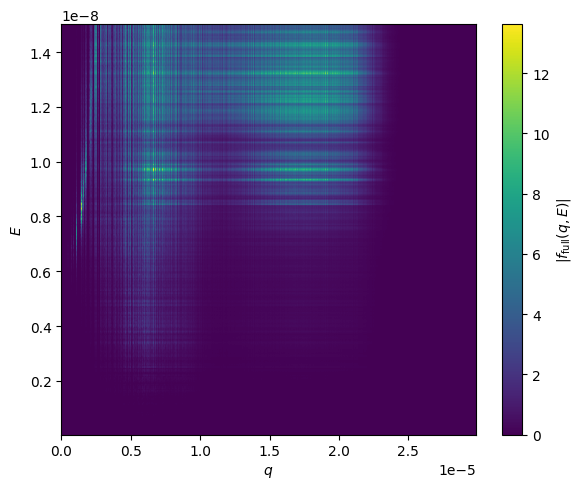

In [13]:
nq_plot = 400
nE_plot = 400
q_plot = np.linspace(q_grid[0], q_grid[-1], nq_plot)
E_plot = np.linspace(E_grid[0], E_grid[-1], nE_plot)

Q_fine, E_fine = np.meshgrid(q_plot, E_plot, indexing="xy")
points = np.stack([Q_fine.ravel(), E_fine.ravel()], axis=-1)

FF_fine = ff_full(points).reshape(E_fine.shape)  # (nE_plot, nq_plot)

plt.figure(figsize=(6, 5))
pcm = plt.pcolormesh(
    Q_fine, E_fine,
    FF_fine,
    shading="auto"
)

plt.xlabel(r"$q$")
plt.ylabel(r"$E$")
cbar = plt.colorbar(pcm)
cbar.set_label(r"$|f_{\rm full}(q, E)|$")

plt.tight_layout()
plt.show()

In [4]:
# Halo DM parameters, just in case
rho_DM  = 0.3 * nu.GeV / nu.cm**3
# frac_DM = 1.0   # Adjust later, fix it to be 1 for now.
vesc    = 544.0 * nu.km / nu.sec
v0      = 238.0 * nu.km / nu.sec
v_Earth = 250.2 * nu.km / nu.sec

# DM speed distribution
Nesc = np.pi * v0 * v0 * (np.sqrt(np.pi) * v0 * erf(vesc / v0) - 2 * vesc * np.exp(-vesc * vesc / v0 / v0))
def f_halo(v, vEarth = v_Earth):
	return np.pi * v * v0 * v0 / Nesc / vEarth * (2 * np.exp(-(v * v + vEarth * vEarth) / v0 / v0) * np.sinh(2 * v * vEarth / v0 / v0) + (np.exp(-np.power(v + vEarth, 2.0) / v0 / v0) - np.exp(-vesc * vesc / v0 / v0)) * np.heaviside(np.abs(v + vEarth) - vesc, 0) - (np.exp(-np.power(v - vEarth, 2.0) / v0 / v0) - np.exp(-vesc * vesc / v0 / v0)) * np.heaviside(np.abs(v - vEarth) - vesc, 0))

def EtaFunction(vMin, vE = v_Earth):
    xMin = vMin / v0
    xEsc = vesc / v0
    xE = vE / v0
    eta = 0.0
    if xMin > xE + xEsc:
        eta = 0.0
    elif np.abs(xMin - xE - xEsc) < 1e-8:
        eta = 0.0
    elif xMin > np.abs(xE - xEsc):
        eta = np.power(np.pi, 1.5) * v0 * v0 / 2.0 / Nesc / xE * (erf(xEsc) - erf(xMin - xE) - 2.0 / np.sqrt(np.pi) * (xE + xEsc - xMin) * np.exp(-xEsc * xEsc))
    elif xEsc > xE:
        eta = np.power(np.pi, 1.5) * v0 * v0 / 2.0 / Nesc / xE * (erf(xMin + xE) - erf(xMin - xE) - 4.0 / np.sqrt(np.pi) * xE * np.exp(-xEsc * xEsc))
    else:
        eta = 1.0 / v0 / xE
    return eta

In [98]:
q_grid[0] / nu.eV

np.float64(37.289394707275235)

In [104]:
qe_int_grid = np.linspace(0.1, 100, 1000) * nu.eV
qi = qe_int_grid * A["hg"] * nu.AMU / nu.mElectron

def v_min(q, Ee, mDM):
    return Ee/q + q/2/mDM

v_min(qi, 1*nu.eV, 1)

array([4.56309780e-05, 5.02394791e-05, 6.39640862e-05, 7.99677198e-05,
       9.68829640e-05, 1.14254013e-04, 1.31885523e-04, 1.49679820e-04,
       1.67582643e-04, 1.85561433e-04, 2.03595472e-04, 2.21670947e-04,
       2.39778298e-04, 2.57910692e-04, 2.76063122e-04, 2.94231831e-04,
       3.12413946e-04, 3.30607232e-04, 3.48809927e-04, 3.67020617e-04,
       3.85238162e-04, 4.03461627e-04, 4.21690239e-04, 4.39923355e-04,
       4.58160435e-04, 4.76401020e-04, 4.94644723e-04, 5.12891208e-04,
       5.31140188e-04, 5.49391413e-04, 5.67644666e-04, 5.85899757e-04,
       6.04156519e-04, 6.22414805e-04, 6.40674483e-04, 6.58935438e-04,
       6.77197566e-04, 6.95460775e-04, 7.13724982e-04, 7.31990111e-04,
       7.50256095e-04, 7.68522874e-04, 7.86790391e-04, 8.05058596e-04,
       8.23327444e-04, 8.41596892e-04, 8.59866903e-04, 8.78137440e-04,
       8.96408473e-04, 9.14679970e-04, 9.32951905e-04, 9.51224253e-04,
       9.69496990e-04, 9.87770094e-04, 1.00604355e-03, 1.02431733e-03,
      

In [ ]:
# To determine light or heavy mediator, just in case
mA = 0.0

def F_DM(q):
    return ((nu.aEM*nu.mElectron)**2 + mA**2)/(q**2 + mA**2)

def v_min(q, Ee, mDM):
    return Ee/q + q/2/mDM

# Energy spectrum per mass:
def dRdEe_halo(Ee, sigma_n, mDM):
    integral  = 0.0
    qe_int_grid = np.linspace(0.1, 100, 1000) * nu.eV
    dqe = qe_int_grid[1] - qe_int_grid[0]
    for target in ("hg", "cd", "te"):
        prefactor = weight[target] * rho_DM / mDM / M_cell * nu.aEM * sigma_n * nu.mElectron**2 * (f_p * Z[target] + f_n * (A[target] - Z[target]))**2 / nu.Reduced_Mass(nu.mProton, mDM)**2
        for qi_e in qe_int_grid:
            qi = qi_e * A[target] * nu.AMU / nu.mElectron
            dqi = A[target] * nu.AMU / nu.mElectron * dqe
            vMin = v_min(qi, Ee, mDM)
            if qi_e <= q_grid[0]:
                ff_qiE = ff_full((q_grid[0], Ee)) * qi_e**2 / q_grid[0]**2   # Dipole approx
            else:
                ff_qiE = ff_full((qi_e, Ee))
            
            integral += prefactor * dqi * qi / qi_e**3 * EtaFunction(vMin) * F_DM(qi)**2 * ff_qiE

    return integral

# Charge Yield:
def charge_yield(Ee, Q):
    if Ee < energy_gap:
        return 0
    else:
        Ee_1 = epsilon * (Q - 1) + energy_gap
        Ee_2 = epsilon * Q + energy_gap
        if Ee < Ee_1 or Ee > Ee_2:
            return 0.0
        else:
            return 1.0

# Electron spectrum per mass:
def R_Q_halo(Q, sigma_n, mDM):
    R_Q = 0
    for Ei in E_grid:
        cy = charge_yield(Ei, Q)
        R_Q += dE * cy * dRdEe_halo(Ei, sigma_n, mDM)
    return R_Q

In [12]:
ff_full((q_grid[100], E_grid[200]))

array(1.22975397)

In [107]:
dRdEe_halo(1*nu.eV, 1e-20 * nu.cm**2, 100*nu.GeV)

np.float64(0.0)

In [90]:
# JWST parameters
pixel_mass = 1.2e-8 *nu.gram
exposure_time   = 3574.278 *nu.sec * 244 / 245  # since we are using (last frame - first frame)
exposure = pixel_mass * exposure_time

log_m_min  = -3
log_m_max  = 1
n_m    = 9   # From 1e-3  to 10 GeV
m_grid      = np.logspace(log_m_min, log_m_max, n_m) * nu.GeV

cs_test = 1e-26 * nu.cm * nu.cm

# center_line = np.array([2.15504637e-23, 1.53030461e-23, 1.26359147e-23, 1.61669130e-23,
#       2.40008514e-23, 4.03532201e-23, 6.95747264e-23, 1.40957345e-22,
#       2.84518575e-22, 5.17381239e-22, 1.08351297e-21, 2.15203017e-21,
#       4.12016417e-21, 7.78952222e-21, 1.45615810e-20, 2.70914228e-20,
#       4.94000000e-20]) * nu.cm * nu.cm

In [91]:
def compute(j):
    m = m_grid[j]
    cs = cs_test
    nq = np.zeros(10)
    for q in range(10):
        print('calculating: i=' + str(j) + ' q=' + str(q) +'\n')
        nq[q] = exposure * R_Q_halo(q+1, cs, m)
    
    np.savetxt('../data/binned_signal_halo_migdal/binned_signals_Halo_'+ str(j) + '.txt', nq, header=str(m))
    return 0

In [92]:
arr = np.linspace(0, 8, 9, dtype=int)
with concurrent.futures.ProcessPoolExecutor() as executor:
    executor.map(compute, arr)

calculating: i=0 q=0
calculating: i=2 q=0
calculating: i=1 q=0
calculating: i=5 q=0
calculating: i=4 q=0
calculating: i=3 q=0
calculating: i=8 q=0
calculating: i=6 q=0
calculating: i=7 q=0









calculating: i=2 q=1

calculating: i=0 q=1

calculating: i=3 q=1

calculating: i=4 q=1

calculating: i=5 q=1

calculating: i=1 q=1

calculating: i=7 q=1

calculating: i=6 q=1

calculating: i=8 q=1

calculating: i=0 q=2

calculating: i=2 q=2

calculating: i=3 q=2

calculating: i=1 q=2

calculating: i=4 q=2

calculating: i=5 q=2

calculating: i=6 q=2

calculating: i=7 q=2

calculating: i=8 q=2

calculating: i=2 q=3

calculating: i=0 q=3

calculating: i=3 q=3

calculating: i=4 q=3

calculating: i=1 q=3

calculating: i=5 q=3

calculating: i=6 q=3

calculating: i=7 q=3

calculating: i=8 q=3

calculating: i=2 q=4

calculating: i=3 q=4

calculating: i=0 q=4

calculating: i=1 q=4

calculating: i=4 q=4

calculating: i=5 q=4

calculating: i=6 q=4

calculating: i=7 q=4

calculating: i=8 q=4

calculatin